<a href="https://colab.research.google.com/github/bforoura/GENAI26/blob/main/Module5/Research_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

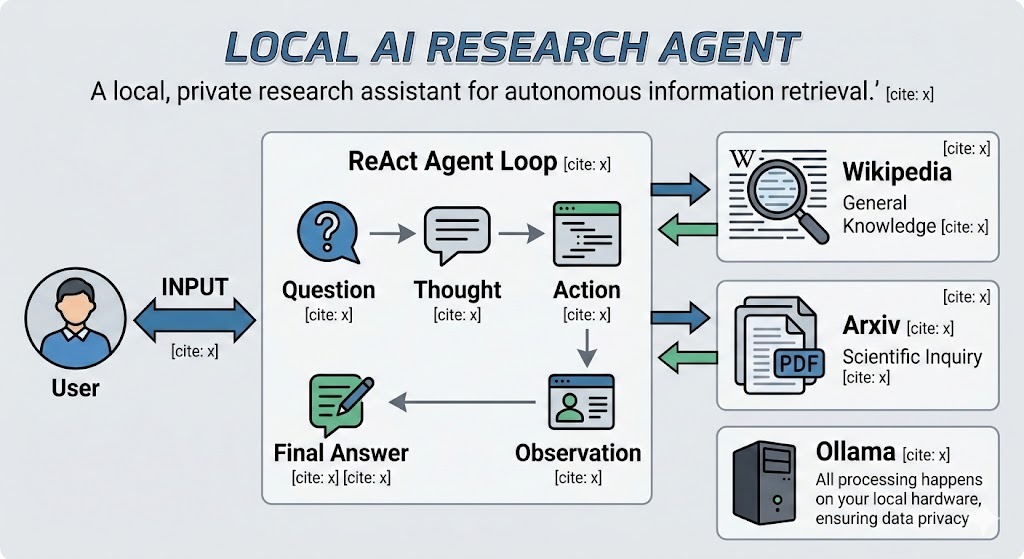
* The purpose of this agent is to provide locally-hosted Research Assistant that uses an LLM to perform information retrieval.

* The agent is equipped with two primary capabilities:

   1. **General Knowledge**: It can search Wikipedia to provide historical context, biographies, and general factual overviews.

   2. **Scientific Inquiry**: It can query Arxiv to find the latest scientific papers, abstracts, and technical research.

* By running on **Ollama**, all processing happens on your local hardware, ensuring data privacy.

* The agent does not just "**chat**"; it thinks through a problem, decides which tool is most appropriate for the question, executes a search, and synthesizes the findings into a comprehensive final answer.

## **0. Installation Setup**

* Below are the imports and the core libraries required for the application to run locally on your laptop.

* It utilizes **Streamlit** for the web interface, **LangChain Ollama** for local model integration, and the **LangChain Classic** package to maintain compatibility with the AgentExecutor and ReAct logic.

In [ ]:
# Install Streamlit for the web interface
pip install streamlit

# Install LangChain and the Ollama integration
pip install langchain-ollama langchain-community

# Install the classic compatibility package for AgentExecutor
pip install langchain-classic

# Install the specific research tool libraries
pip install wikipedia arxiv requests

In [ ]:
import streamlit as st
from langchain_ollama import ChatOllama
# Corrected Imports for LangChain v1.0+ compatibility
from langchain_classic.agents import AgentExecutor, create_react_agent
from langchain_community.tools import WikipediaQueryRun, ArxivQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langchain_core.prompts import PromptTemplate

## **1. Tool Initialization**


* Initialize the external tools for the agent.

* **Wikipedia** is configured with a **WikipediaAPIWrapper** to fetch the top result and limit the text length to ensure the local LLM isn't overwhelmed.

* **Arxiv** is configured to search and retrieve scientific abstracts.

* These tools are then **bundled** into a **tools list** that the agent will use to make decisions.

In [ ]:
############################################################################################
# Initialize Research Tools
# Using wrappers to limit the data sent to the local LLM
############################################################################################

wiki_wrapper = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=1000)
wiki_tool = WikipediaQueryRun(api_wrapper=wiki_wrapper)

arxiv_wrapper = ArxivAPIWrapper(top_k_results=1, doc_content_chars_max=1000)
arxiv_tool = ArxivQueryRun(api_wrapper=arxiv_wrapper)

# Tool list restricted to Wikipedia and Arxiv
tools = [wiki_tool, arxiv_tool]



## **2. Local LLM Configuration**

* This section defines the engine of the agent.

* It uses **ChatOllama** to connect to a model running on your local machine **defaulting to qwen2.5-coder:3b**

* The temperature is set to 0 to ensure the agent's responses are factual and consistent rather than creative.

In [ ]:

############################################################################################
# Agent Configuration
# Ensure Ollama is running locally with the qwen2.5-coder:3b model
############################################################################################

llm = ChatOllama(model="qwen2.5-coder:3b", temperature=0)



## **3. ReAct Prompt Engineering**

* This defines the **Reasoning and Acting** (**ReAct**) framework.

* The template instructs the LLM on how to structure its internal monologue using a specific sequence: **Question → Thought → Action → Observation**

* This ensures the agent "**thinks**" before it uses a tool and evaluates the result before answering.

In [ ]:
############################################################################################
# ReAct Prompt Template
############################################################################################
template = """Answer the following questions as best you can. You have access to the following tools:

{tools}

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [{tool_names}]
Action Input: the input to the action
Observation: the result of the action
... (this Thought/Action/Action Input/Observation can repeat N times)
Thought: I now know the final answer
Final Answer: the final answer to the original input question

Begin!

Question: {input}
Thought:{agent_scratchpad}"""

prompt = PromptTemplate.from_template(template)

# Build the ReAct Agent using the modern constructor
agent = create_react_agent(llm, tools, prompt)


## **4. Agent and Executor Logic**

* In this section, we **compile** the **agent**.

* **create_react_agent**  combines the LLM, the tools, and the prompt template into a single logic unit.

* The **AgentExecutor** then manages the loop, handling potential parsing errors and providing a "**verbose**" output so we can see the **agent's thought** process in the terminal.

In [ ]:
############################################################################################
# Create the executor using the classic compatibility layer
############################################################################################
agent_executor = AgentExecutor(
    agent=agent,
    tools=tools,
    verbose=True,
    handle_parsing_errors=True
)



## **5. Streamlit UI Layout**


* This section **configures** the **web frontend.**

* It sets the page title, layout, and header text.

*  It provides the user with clear instructions that this specific agent is dedicated to searching **Wikipedia** and **Arxiv**.


In [ ]:
############################################################################################
# Streamlit User Interface
############################################################################################

st.set_page_config(page_title="Local Research Assistant", layout="wide")
st.title("Local AI Research Agent")
st.markdown("This agent uses Wikipedia for general facts and Arxiv for scientific papers.")



## **6. Session State Management**

* To make the application feel like a real chat, we initialize a "**session state**" to store the message history.

* This prevents the conversation from being wiped every time the Streamlit script reruns which happens after every user interaction.

In [ ]:
############################################################################################
# Initialize session state for chat history
############################################################################################
if "messages" not in st.session_state:
    st.session_state.messages = []

# Render chat history
for message in st.session_state.messages:
    with st.chat_message(message["role"]):
        st.markdown(message["content"])

# User interaction logic
if user_input := st.chat_input("Ask a research question..."):
    st.session_state.messages.append({"role": "user", "content": user_input})
    with st.chat_message("user"):
        st.markdown(user_input)

    with st.chat_message("assistant"):
        with st.spinner("Searching sources..."):
            try:
                # Invoke the agent executor
                response = agent_executor.invoke({"input": user_input})
                final_answer = response["output"]
            except Exception as e:
                final_answer = f"Error during agent execution: {str(e)}"

            st.markdown(final_answer)
            st.session_state.messages.append({"role": "assistant", "content": final_answer})

# **How to Launch the Streamlit App**


* Once your dependencies are installed and the code is saved; e.g., as **research_agent_app.py**, follow these steps:

* Open your Terminal and navigate to the folder where you saved your Python file.

* Run the Streamlit command: `streamlit run research_agent_app.py`

* Streamlit will automatically open a new tab in your default web browser usually at http://localhost:8501


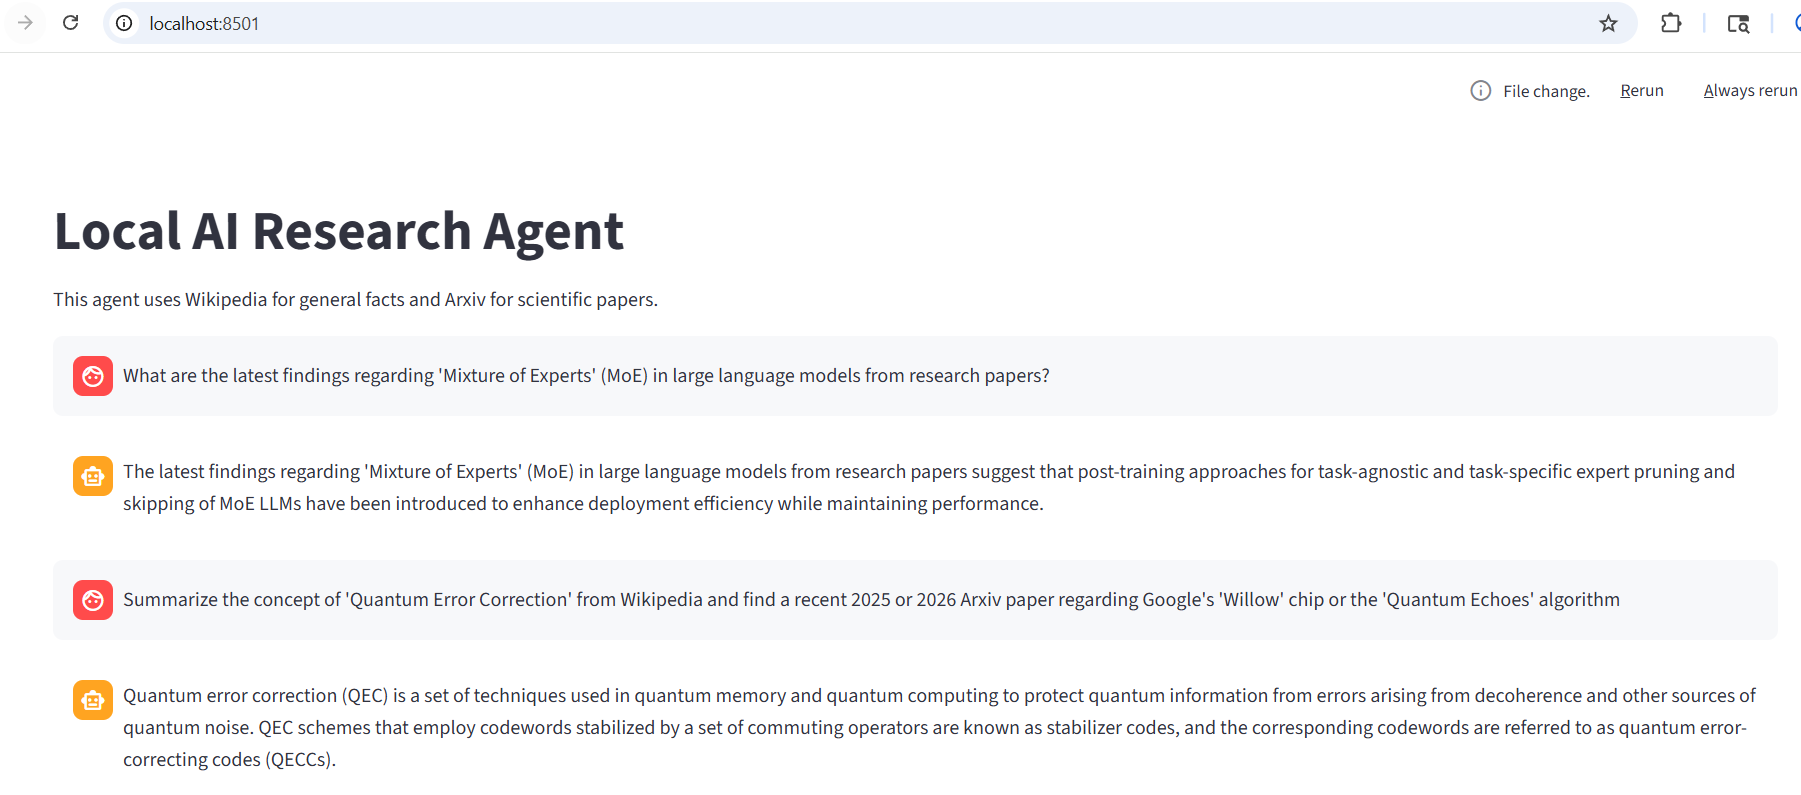